## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [2]:
df = pd.read_csv("Country-data.csv",index_col=False)
df_copy = df.copy()
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Data Details

In [3]:
print(f"Shape: {df.shape}")
df.info()

Shape: (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [4]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [5]:
df.duplicated().sum()

0

## Change column Type to numeric

In [6]:
for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

**About Data**
* No null values found
* No duplicated found 

## 1. EDA — Univariate Analysis

### Numerical

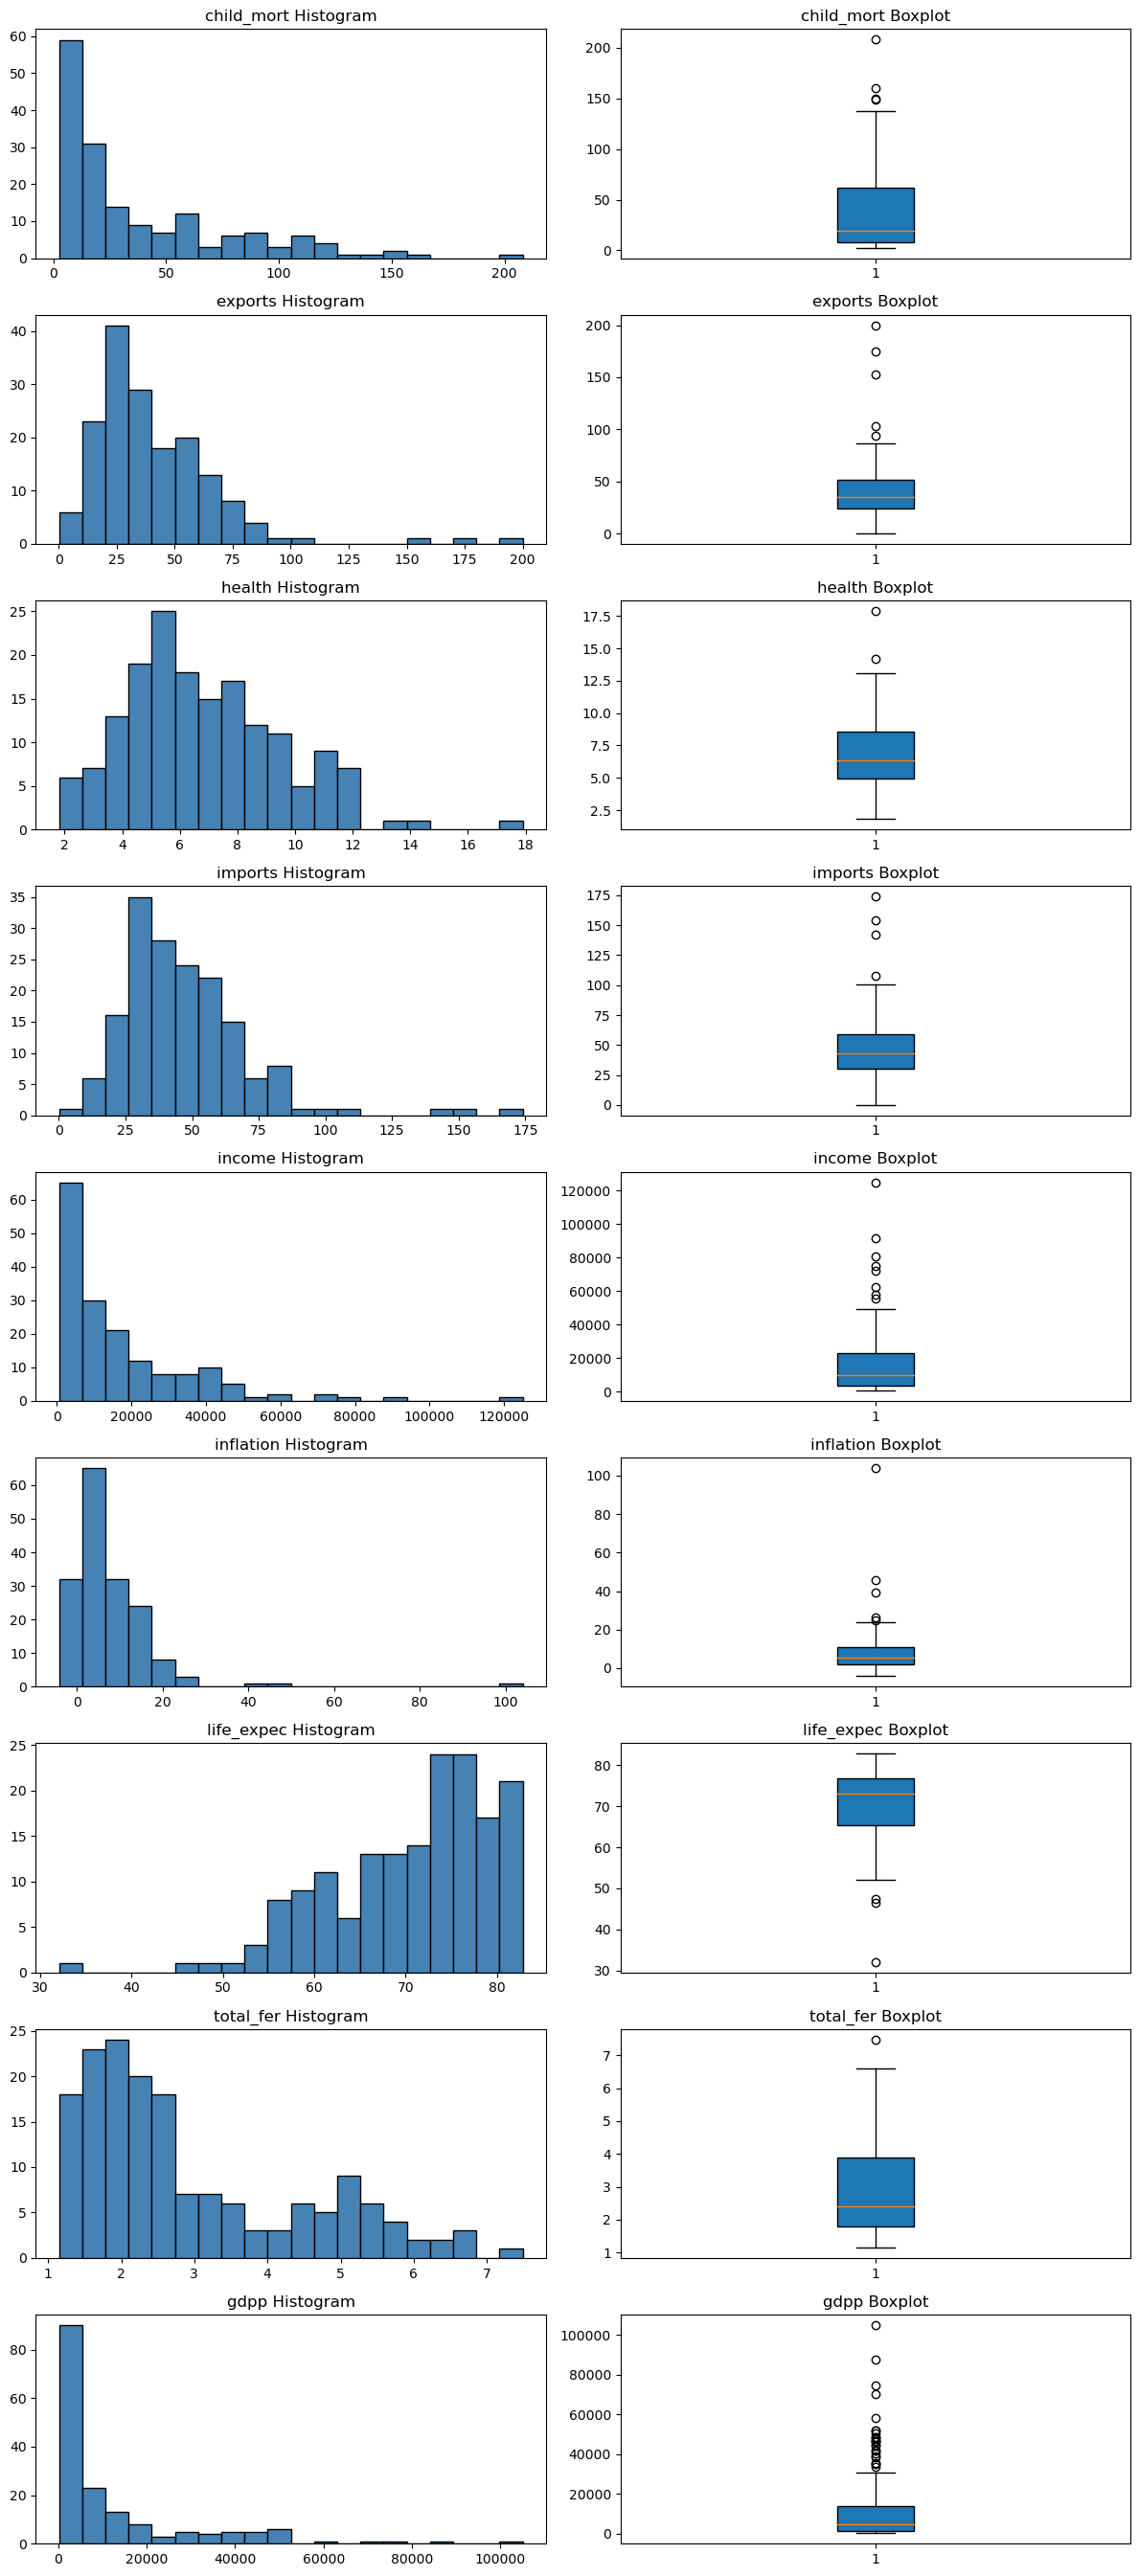

In [7]:
plot_num = [col for col in df.columns if col not in ['country']]

fig, axes = plt.subplots(len(plot_num), 2, figsize=(12, len(plot_num) * 3))

for i, col in enumerate(plot_num):
    axes[i, 0].hist(df[col], bins=20, color='steelblue', edgecolor='black')
    axes[i, 0].set_title(f'{col} Histogram')

    axes[i, 1].boxplot(df[col], patch_artist=True)
    axes[i, 1].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

# Bivariate: Correlation Heatmap

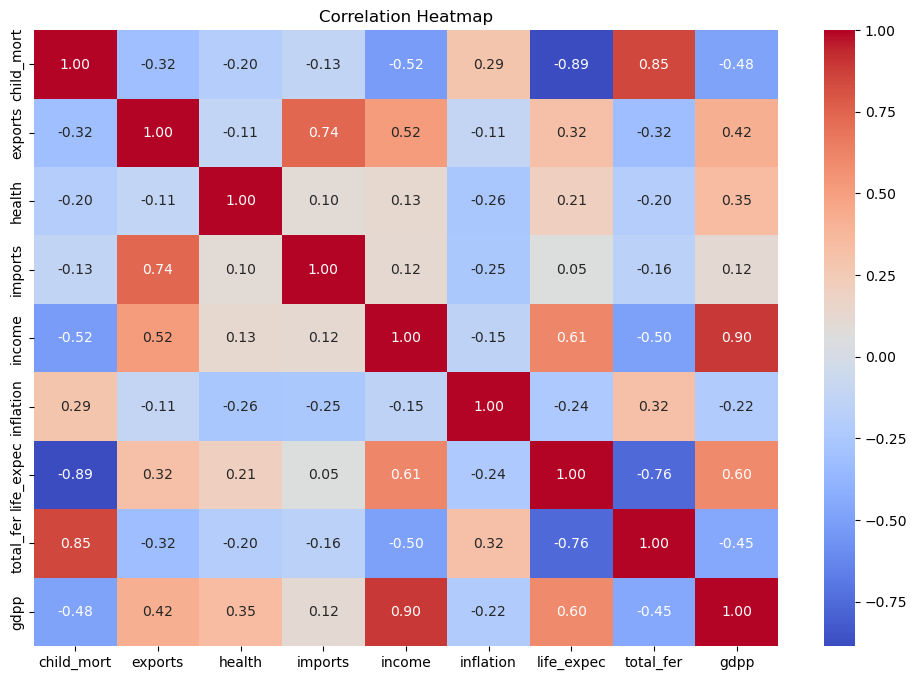

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## About EDA 
**Univariate Analysis**
* Data is not normally distribited mostly left skewed
* Outliers are also there in many columns

**Bivariate Analysis**
* Income and GDP is corr 0.90 (high)
* child_mort and total_fer corr 0.85 (high)
* export and import corr 0.74 (mid)
* life_exp and Gdp corr 0.60 (mid)
* health and inflation no or least corr with any other columns

# 2 Feature Scaling

In [9]:
data_scaled = df.copy()

num_Col = [i for i in df.columns if i!='country']
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(data_scaled[num_Col])

## 3. K-Means Clustering

### Elbow Method

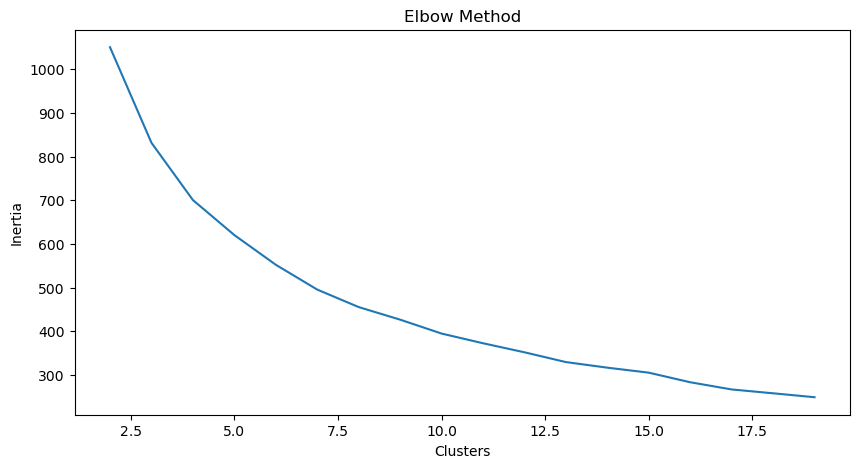

In [10]:
inertia = []
k_values = range(2,20)

max_ = {}

for k in k_values:
    k_mean = KMeans(n_clusters=k, random_state=42, n_init=20)
    k_mean.fit(X_scaled)
    inertia.append(k_mean.inertia_)
    score = silhouette_score(X_scaled, k_mean.fit_predict(X_scaled))
    max_[k]=score

plt.figure(figsize=(10, 5))
plt.plot(list(k_values), inertia)
plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('Inertia')
plt.show()

In [11]:
print(max_)

{2: 0.28735668921406704, 3: 0.28329575683463126, 4: 0.301375962376881, 5: 0.2992594995920442, 6: 0.2330296024929803, 7: 0.24905003461730515, 8: 0.2414024552159115, 9: 0.20340692932613638, 10: 0.20150345460677085, 11: 0.1979613096161359, 12: 0.19523927451398804, 13: 0.21273563916943194, 14: 0.20401835254304332, 15: 0.1970984348875979, 16: 0.2057072621951584, 17: 0.2197522284372101, 18: 0.2030009200986933, 19: 0.20521270946419665}


In [12]:
print("Max silhouette_score: ", max(max_.values()), "For: ",4)

Max silhouette_score:  0.301375962376881 For:  4


# Feature Selection(Dimention Reduction)

In [13]:
scaled_df = pd.DataFrame(X_scaled, columns=num_Col)
scaled_df.drop(columns = ['inflation','health'], inplace=True)

In [14]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
kmeans.fit(scaled_df)
silhouette_score(scaled_df, kmeans.labels_)

0.351843841429834

* I've oberved in the EDA that health and inflation had no correlation with any column it might be causing problem
* and i was right about it

In [15]:
scaled_df.drop(columns = ['exports','imports'], inplace=True)

In [16]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
kmeans.fit(scaled_df)
silhouette_score(scaled_df, kmeans.labels_)

0.45853562539209164

* I played with more columns and when i removed export and import which were correlating 0.74 score rised more by 0.10

### Elbow method again on updated scaled df

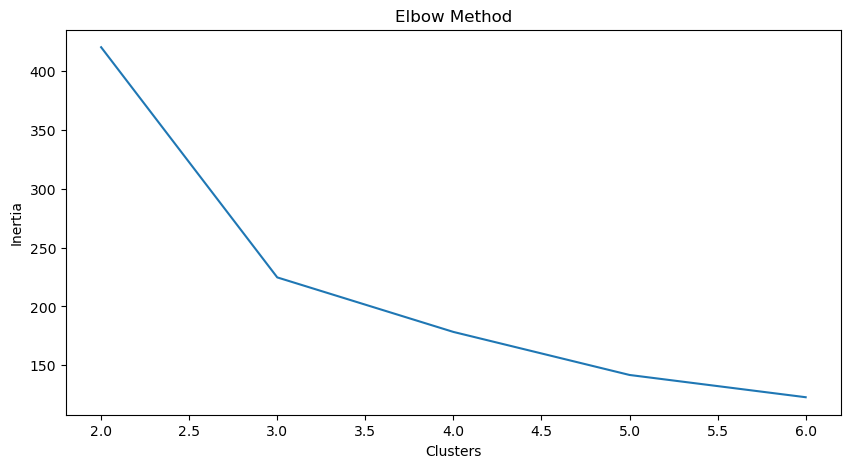

In [17]:
intr = []
k_val = range(2,7)

max_ = {}

for k in k_val:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    intr.append(kmeans.inertia_)
    score = silhouette_score(scaled_df, kmeans.labels_)
    max_[k]=score

plt.figure(figsize=(10, 5))
plt.plot(list(k_val), intr)
plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('Inertia')
plt.show()

* Eblow value as per Graph is 3

## Final Model

In [18]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
kmeans.fit(scaled_df)
kmeans_pred = kmeans.fit_predict(scaled_df)
silhouette_score(scaled_df, kmeans.labels_)

0.4994445053213666

## 4. DBSCAN

In [19]:
Dbscan = DBSCAN(eps=1.5, min_samples=8)
Dbscan.fit(scaled_df)
silhouette_score(scaled_df, Dbscan.labels_)

0.5100960794800096

* silhouette_score for DBScan is slight more than Kmeans 

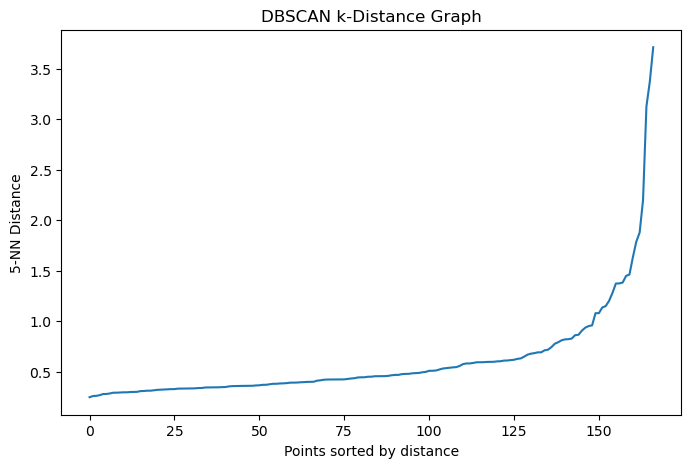

In [20]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(scaled_df)

distances, indices = neighbors_fit.kneighbors(scaled_df)

distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN Distance")
plt.title("DBSCAN k-Distance Graph")
plt.show()

In [21]:
# Elbow was around 1.1 - 1.5 i tried 1.5 was correct!

Dbscan = DBSCAN(eps=1.5, min_samples=8)
Dbscan.fit(scaled_df)
Dbscan_pred = Dbscan.fit_predict(scaled_df)
silhouette_score(scaled_df, Dbscan.labels_)

0.5100960794800096

# 5. PCA: DBSCAN

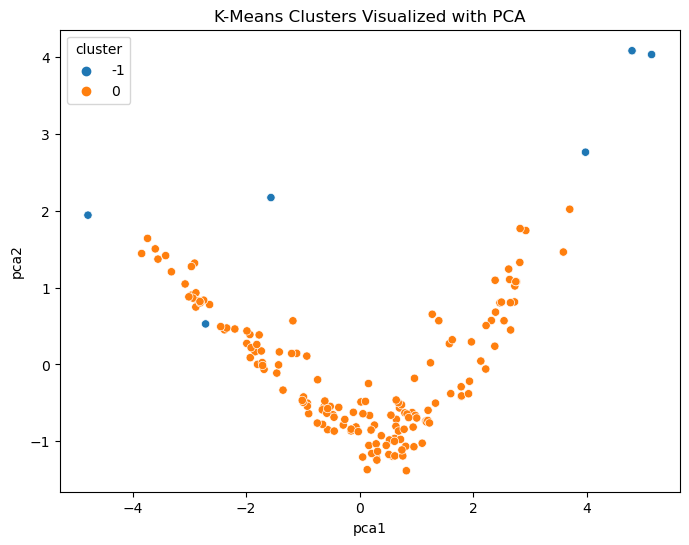

In [22]:
df_copy['Dbscan'] = Dbscan_pred
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(scaled_df)

viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'cluster': df_copy['Dbscan']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='cluster', palette='tab10')
plt.title('K-Means Clusters Visualized with PCA')
plt.show()

**This PCA clearly states that DBSCAN is not at all working Correctly**

# 6 PCA: KMeans

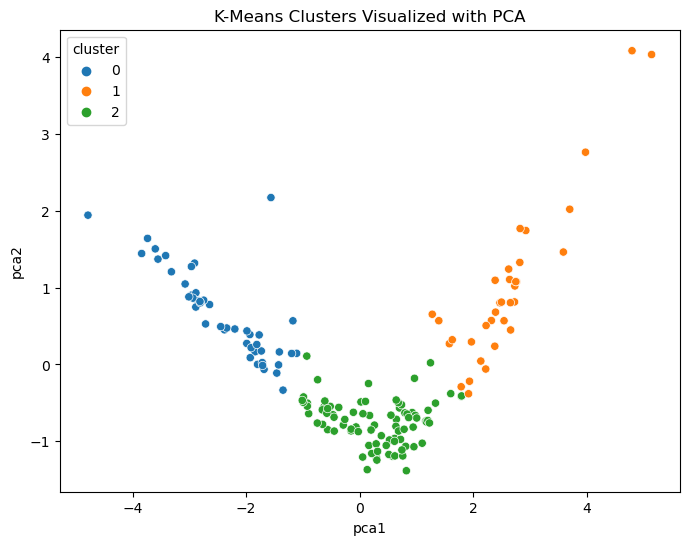

In [23]:
df_copy['kmeans'] = kmeans_pred
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(scaled_df)

viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'cluster': df_copy['kmeans']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='cluster', palette='tab10')
plt.title('K-Means Clusters Visualized with PCA')
plt.show()

# Question/Answers

* Which cluster has high child mortality?
* Which cluster has high income and gdpp?
* Which cluster looks underdeveloped?
* Which countries should be prioritized for aid?

In [24]:
cluster_profile = df_copy.groupby("kmeans")[["child_mort", "income", "gdpp", "life_expec", "total_fer"]].mean().round(2)
cluster_profile

,child_mort,income,gdpp,life_expec,total_fer
kmeans,,,,,
0,92.77,3710.06,1854.09,59.07,5.00
1,5.48,47820.59,43776.47,80.08,1.86
2,21.45,12359.19,6854.33,73.07,2.26


# 1. Which cluster has high child mortality?

ANS:  0 has highest mortality rate


<Axes: xlabel='kmeans', ylabel='child_mort'>

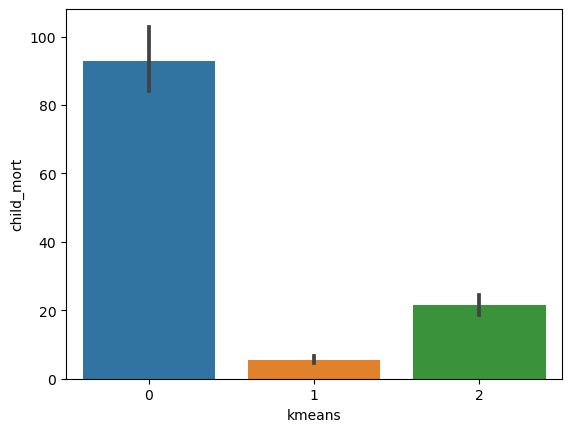

In [25]:
print("ANS: ",cluster_profile["child_mort"].idxmax(),"has highest mortality rate")
plt.ylabel("Average Child Mortality")
sns.barplot(data=df_copy,x="kmeans", y="child_mort")

# 2. Which cluster has high income and gdpp?

ANS:  1 has highest income and GDP


<Axes: xlabel='kmeans'>

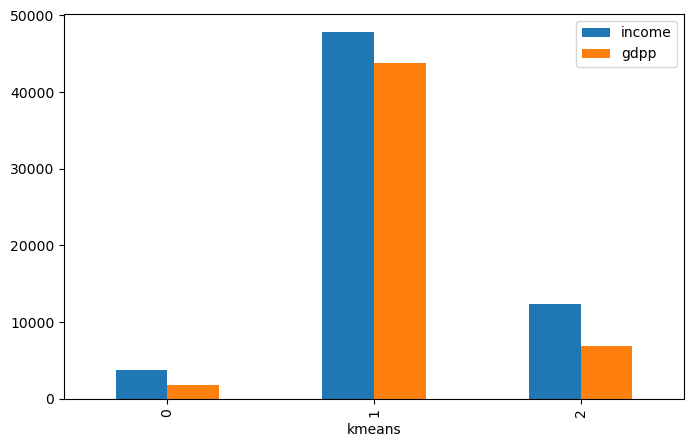

In [26]:
print("ANS: ",cluster_profile[["income","gdpp"]].mean(axis=1).idxmax(),"has highest income and GDP")
cluster_profile[["income", "gdpp"]].plot(kind="bar", figsize=(8,5))

# 3. Which cluster looks underdeveloped?

ANS: Label 1 is underdeveloped


<Axes: xlabel='kmeans'>

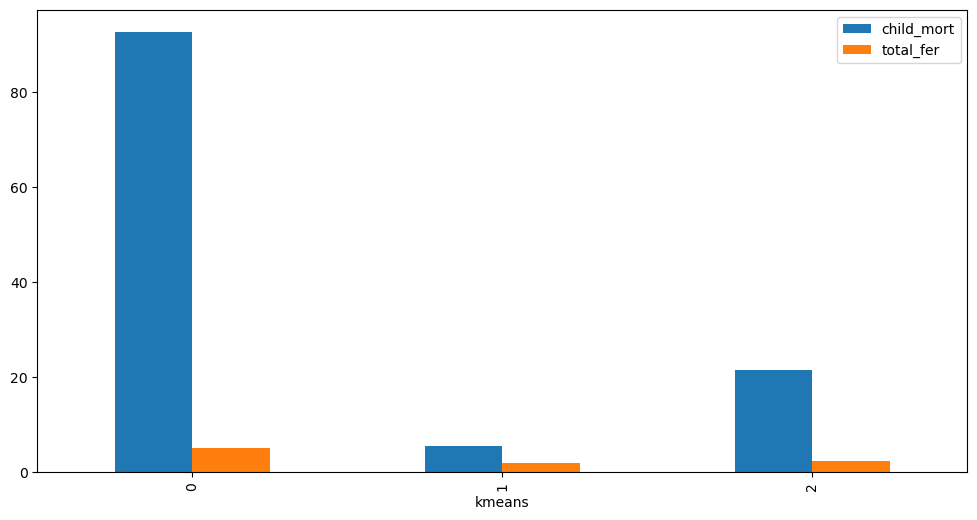

In [27]:
print("ANS: Label 1 is underdeveloped")
cluster_profile[['child_mort','total_fer']].plot(kind="bar", figsize=(12,6))

# 4. Which countries should be prioritized for aid?

In [28]:
print("ANS: Label 1 contries Require AID")
df_copy[df_copy["kmeans"]==1][['country','gdpp']].sort_values(by = 'gdpp')

ANS: Label 1 contries Require AID


,country,gdpp
128,Saudi Arabia,19300
115,Oman,19300
11,Bahrain,20700
138,South Korea,22100
135,Slovenia,23400
60,Greece,26900
74,Israel,30600
139,Spain,30700
42,Cyprus,30800
111,New Zealand,33700


# Conclusion

**KMeans**
* Kmeans is better than DBCAN it's properly classifying the data
* 0: DEVELOPING
* 1: UNDERDEVELOPED
* 2: DEVELOPED
* Best Silhouette Score for Kmeans was 0.499 round off 0.50
* Feature Selection made the model work even well

**On Same Feature i've tried DBCAN but it Failed**